In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('./data/twitter_training.csv')
df.head()

,ID,entity,sentiment,tweet_content
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [36]:
df.shape

(73990, 4)

<Axes: xlabel='sentiment', ylabel='count'>

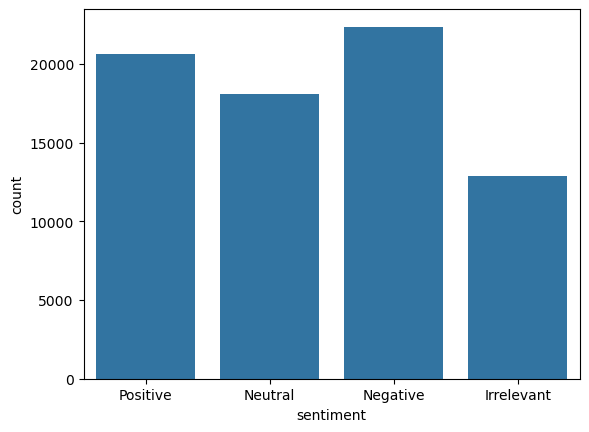

In [37]:
sns.countplot(x='sentiment', data=df)

In [4]:
df['sentiment'].value_counts(normalize=True).mul(100).round(2)

sentiment
Negative      30.18
Positive      27.89
Neutral       24.53
Irrelevant    17.39
Name: proportion, dtype: float64

## Word counts

In [41]:
df['word_count'] = df['tweet_content'].apply(lambda x: len(x.split()))

In [42]:
df['word_count'].describe()

count    73990.000000
mean        19.227963
std         14.442346
min          0.000000
25%          8.000000
50%         16.000000
75%         27.000000
max        198.000000
Name: word_count, dtype: float64

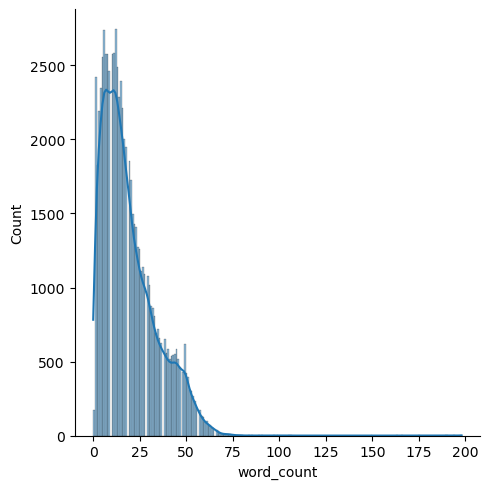

In [43]:
sns.displot(df['word_count'], kde=True)

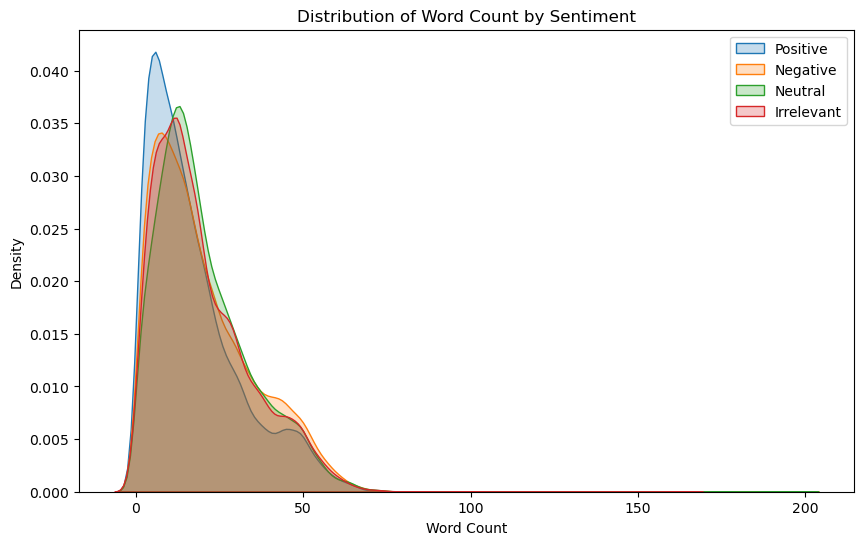

In [56]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot Kde for category Positive
sns.kdeplot(df[df['sentiment'] == 'Positive']['word_count'], label='Positive', fill=True)

# # Plot Kde for category Negative
sns.kdeplot(df[df['sentiment'] == 'Negative']['word_count'], label='Negative', fill=True)

# # Plot Kde for category Neutral
sns.kdeplot(df[df['sentiment'] == 'Neutral']['word_count'], label='Neutral', fill=True)

# # Plot Kde for category Irrelevant
sns.kdeplot(df[df['sentiment'] == 'Irrelevant']['word_count'], label='Irrelevant', fill=True)

# Add labels and title
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Distribution of Word Count by Sentiment')

# Add legend
plt.legend()

# Show the plot 
plt.show()


All these categories show a `right skew-distribution`, with a `noticeable bump` around 50 word counts. Most major comments in these categories are under 50 words, but some comments in the positive, neutral, and negative categories exceed 50 words.

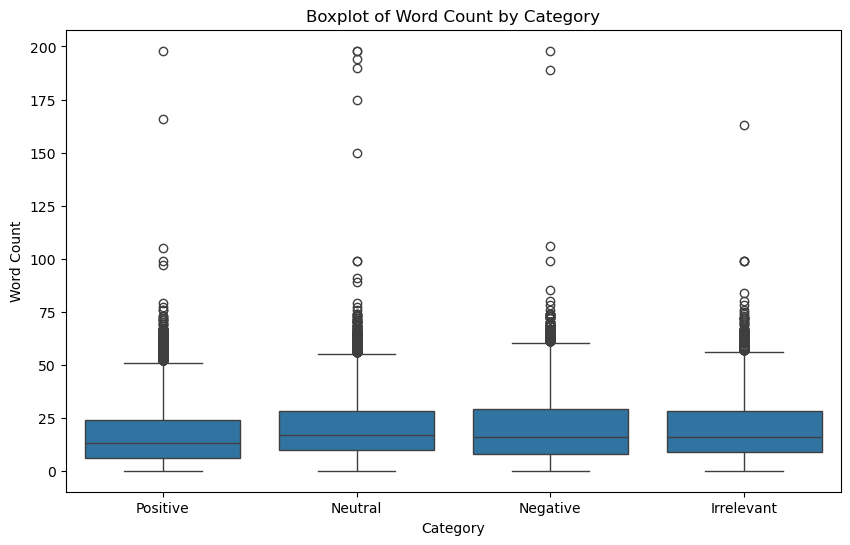

In [60]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Positive tweets**: The median word count is relatively low, and there are plenty of outlier with longer tweets, indicating that positive tweets tend to be more verbose.

**Negative and Irrelevant tweets**: They have similar median , which are relatively higher than that of positive tweets. Irrelevant tweets have higher outliers values than Negative tweets but extreme outliers values are present in negative category.

**Neutral tweets**: The median word count appears to be higher than that of the positive, negative, and irrelevant categories. There are several outliers with longer tweets, and it also has the highest number of extreme outlier values.

<Axes: xlabel='sentiment', ylabel='word_count'>

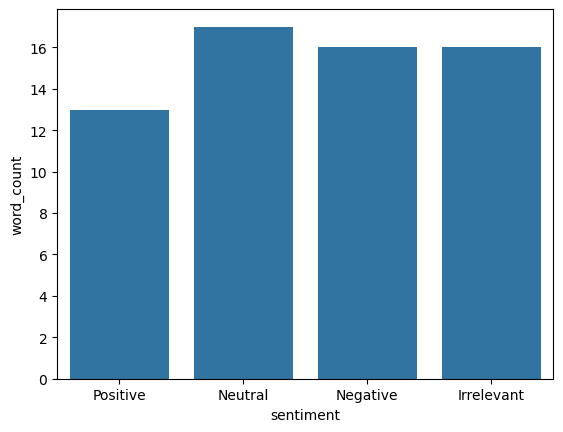

In [61]:
# median word counts among sentiments

sns.barplot(df,x='sentiment',y='word_count',estimator='median')

## Number of stop words

In [64]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))


df['num_stop_count'] = df['tweet_content'].apply(lambda x: len([word for word in x.split() if word.lower()  in stop_words]))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\soura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


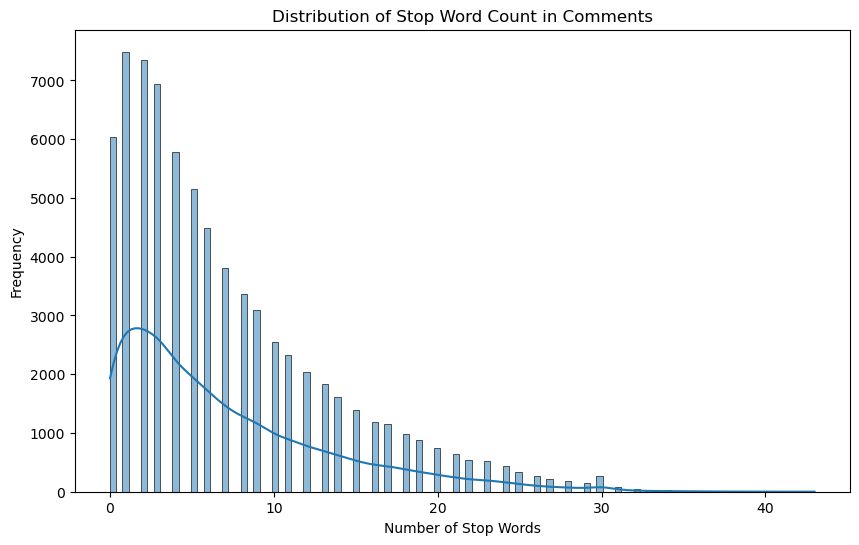

In [66]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_count'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()


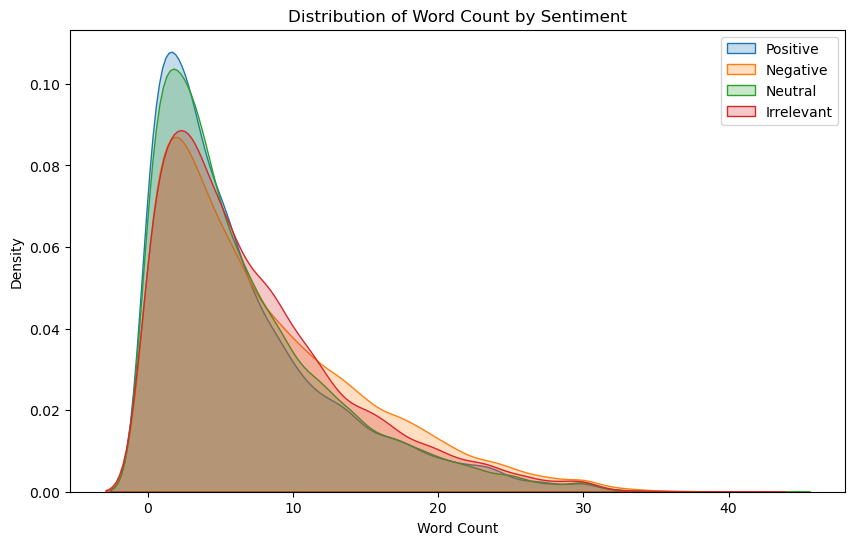

In [67]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot Kde for category Positive
sns.kdeplot(df[df['sentiment'] == 'Positive']['num_stop_count'], label='Positive', fill=True)

# # Plot Kde for category Negative
sns.kdeplot(df[df['sentiment'] == 'Negative']['num_stop_count'], label='Negative', fill=True)

# # Plot Kde for category Neutral
sns.kdeplot(df[df['sentiment'] == 'Neutral']['num_stop_count'], label='Neutral', fill=True)

# # Plot Kde for category Irrelevant
sns.kdeplot(df[df['sentiment'] == 'Irrelevant']['num_stop_count'], label='Irrelevant', fill=True)

# Add labels and title
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Distribution of Word Count by Sentiment')

# Add legend
plt.legend()

# Show the plot 
plt.show()


<Axes: xlabel='sentiment', ylabel='num_stop_count'>

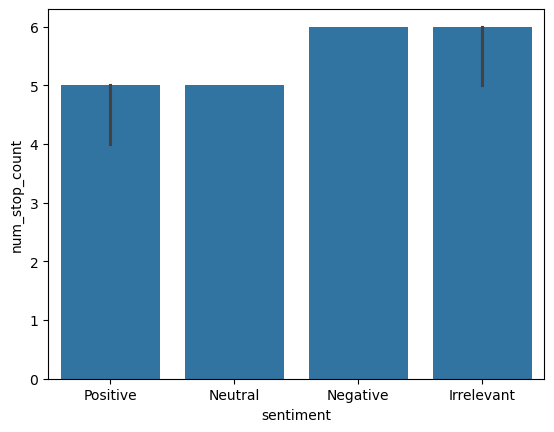

In [68]:
# median word counts among sentiments

sns.barplot(df,x='sentiment',y='num_stop_count',estimator='median')

C:\Users\soura\AppData\Local\Temp\ipykernel_22244\2699354399.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='Stop Word', x='Frequency', data=top_25_df, palette='viridis')


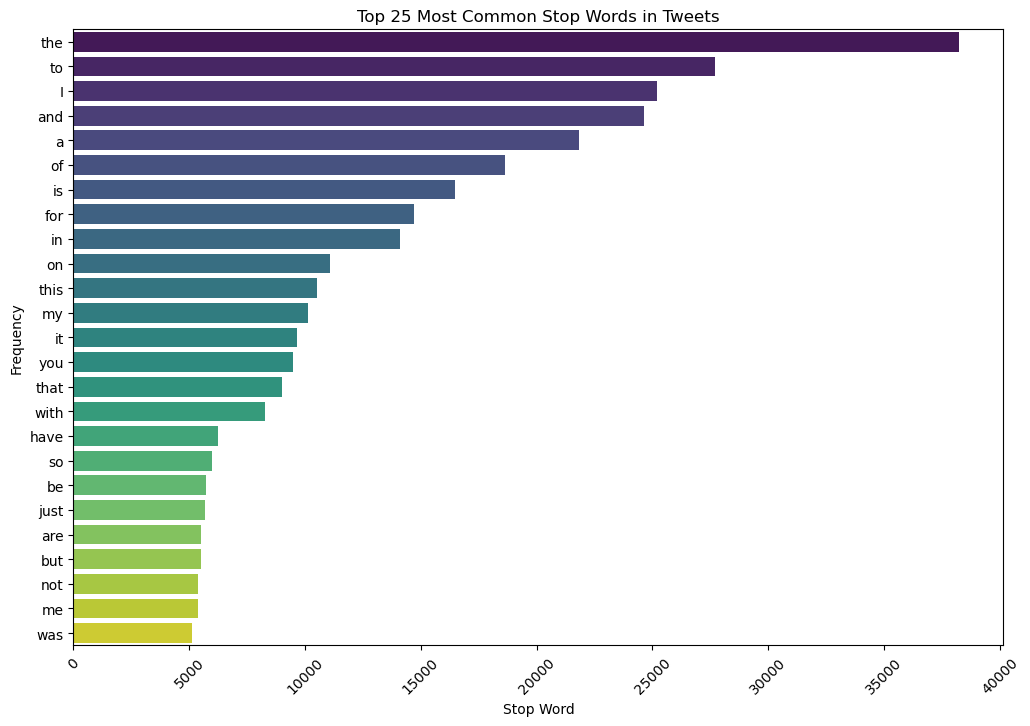

In [78]:
# Create a frequency distribution of stop words in the 'tweet_content' column
from collections import Counter

# Extract all stop words from tweent_content using the previously defined function
all_stop_words = [word for tweet in df['tweet_content'] for word in tweet.split() if word.lower() in stop_words]

# Count the frequency of each stop word
most_common_stop_words = Counter(all_stop_words).most_common(25) 

# convert the most common stop words to a dataframe for visualization
top_25_df = pd.DataFrame(most_common_stop_words, columns=['Stop Word', 'Frequency']) 


# create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(y='Stop Word', x='Frequency', data=top_25_df, palette='viridis')
plt.title('Top 25 Most Common Stop Words in Tweets')
plt.xlabel('Stop Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [81]:
df['num_chars'] = df['tweet_content'].apply(len)
df.head()

,ID,entity,sentiment,tweet_content,word_count,num_stop_count,num_chars
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,12,8,51
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,10,5,50
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,10,5,51
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,12,6,57
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,10,5,53


In [82]:
df['num_chars'].describe()

count    73990.000000
mean       108.791688
std         79.522236
min          1.000000
25%         47.000000
50%         91.000000
75%        153.000000
max        957.000000
Name: num_chars, dtype: float64

In [83]:
from collections import Counter

# Combine all tweets into one large string

all_text = ' '.join(df['tweet_content'])

# Count the frequency of each word
char_counts = Counter(all_text)

# Convert the dictionary to a DataFrame
char_counts_df = pd.DataFrame(char_counts.items(), columns=['Character', 'Frequency']).sort_values('Frequency', ascending=False)
char_counts_df.head()

,Character,Frequency
1,,1435980
11,e,645442
9,t,495075
5,o,473356
2,a,459767


C:\Users\soura\AppData\Local\Temp\ipykernel_22244\3313223646.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


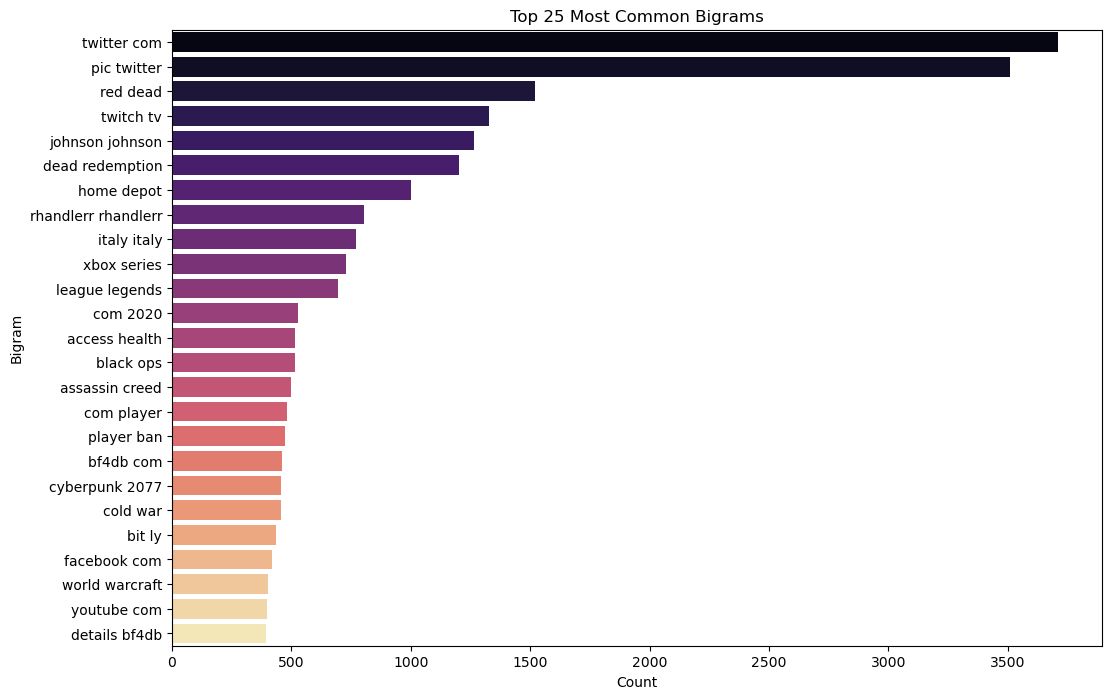

In [90]:
from sklearn.feature_extraction.text import CountVectorizer

# create a function to extract the top 25 bigrams
def get_top_bigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]


# Get the top 25 bigrams
top_25_bigrams = get_top_bigrams(df['tweet_content'], n=25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()

C:\Users\soura\AppData\Local\Temp\ipykernel_22244\1852291936.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


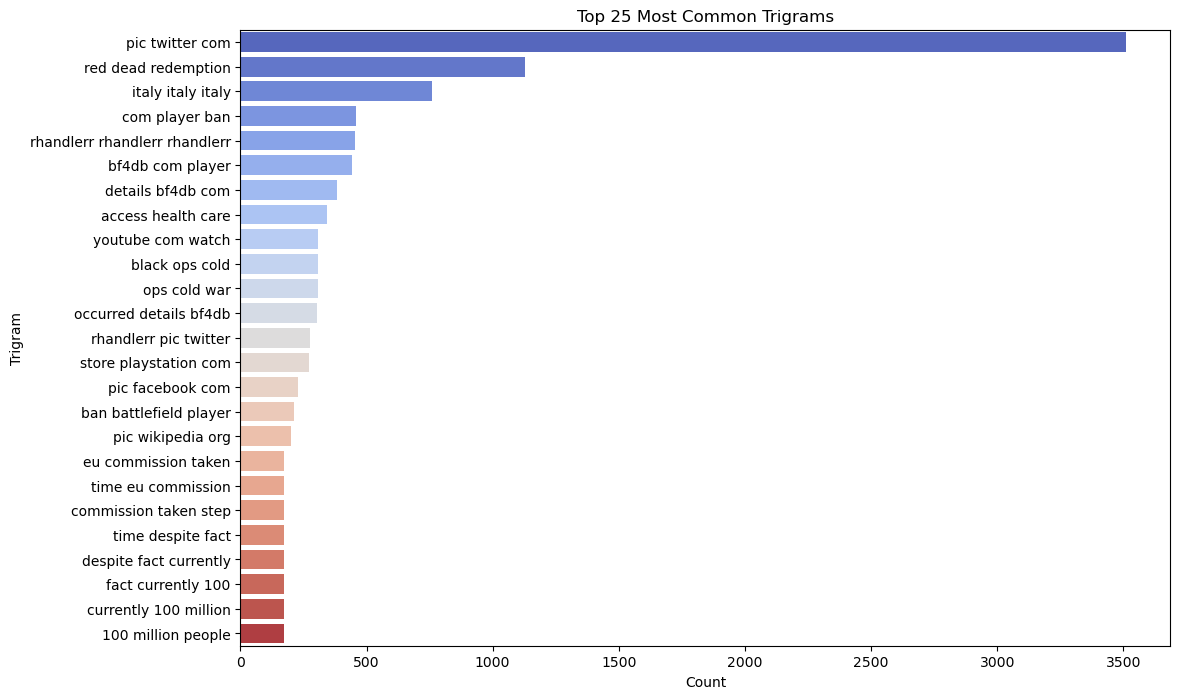

In [91]:
# Create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['tweet_content'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [92]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['tweet_content'] = df['tweet_content'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\soura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,ID,entity,sentiment,tweet_content,word_count,num_stop_count,num_chars
0,2401,Borderlands,Positive,I am coming to the border and I will kill you ...,12,8,51
1,2401,Borderlands,Positive,"im getting on borderland and i will kill you all,",10,5,50
2,2401,Borderlands,Positive,im coming on borderland and i will murder you ...,10,5,51
3,2401,Borderlands,Positive,im getting on borderland 2 and i will murder y...,12,6,57
4,2401,Borderlands,Positive,im getting into borderland and i can murder yo...,10,5,53


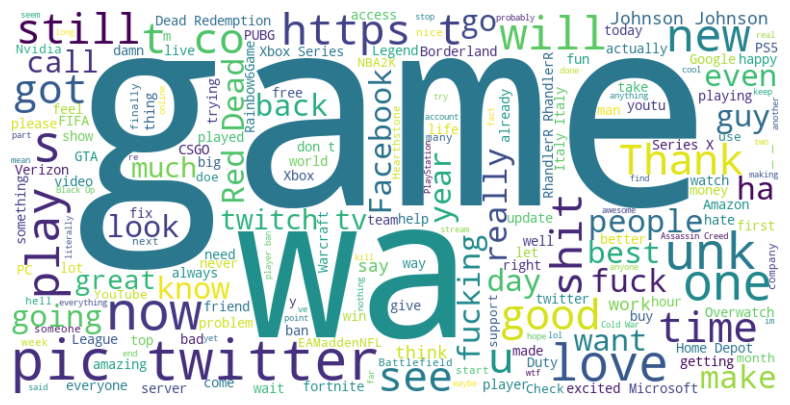

In [93]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['tweet_content'])

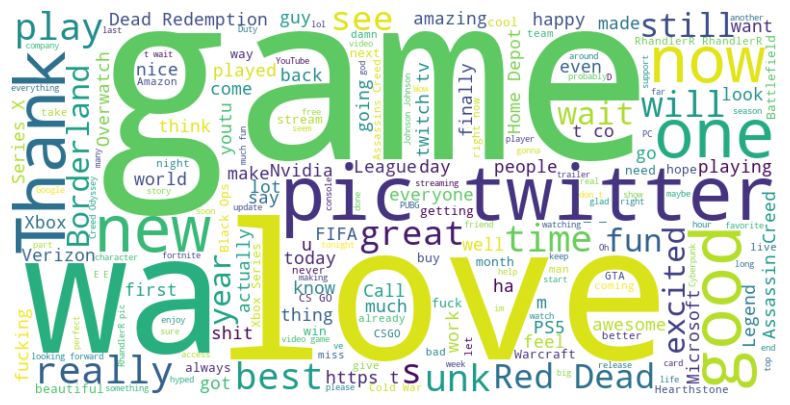

In [97]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['sentiment'] == 'Positive']['tweet_content'])

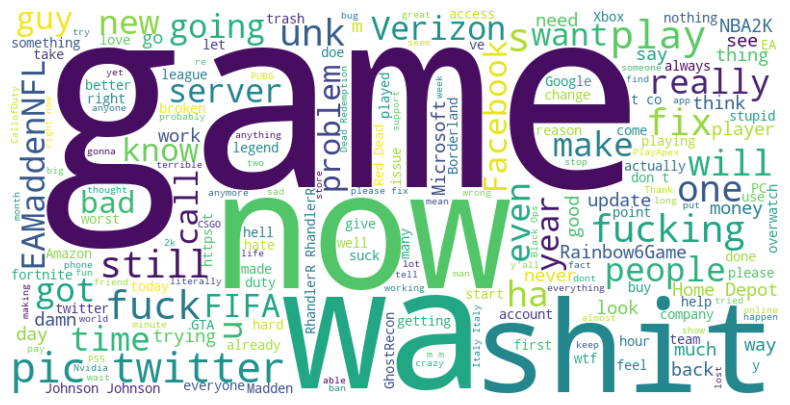

In [98]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['sentiment'] == 'Negative']['tweet_content'])

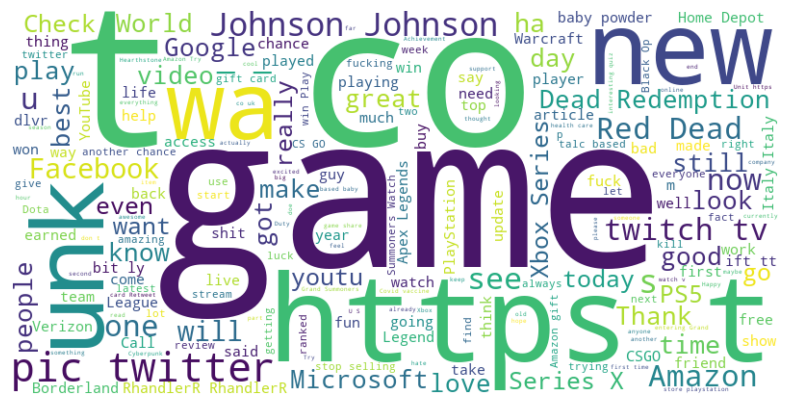

In [99]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['sentiment'] == 'Neutral']['tweet_content'])

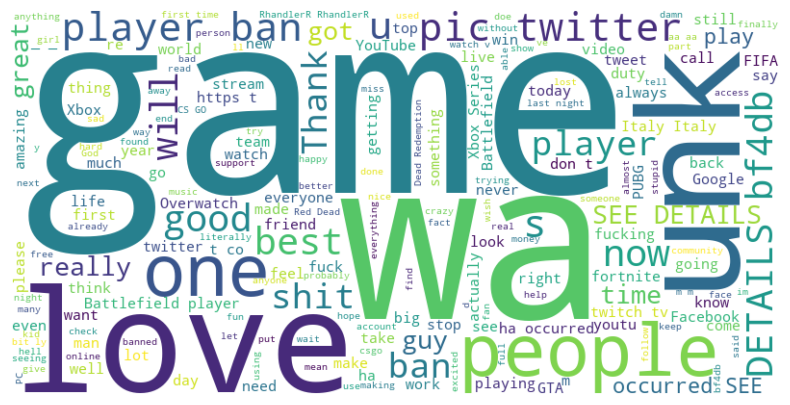

In [100]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['sentiment'] == 'Irrelevant']['tweet_content'])

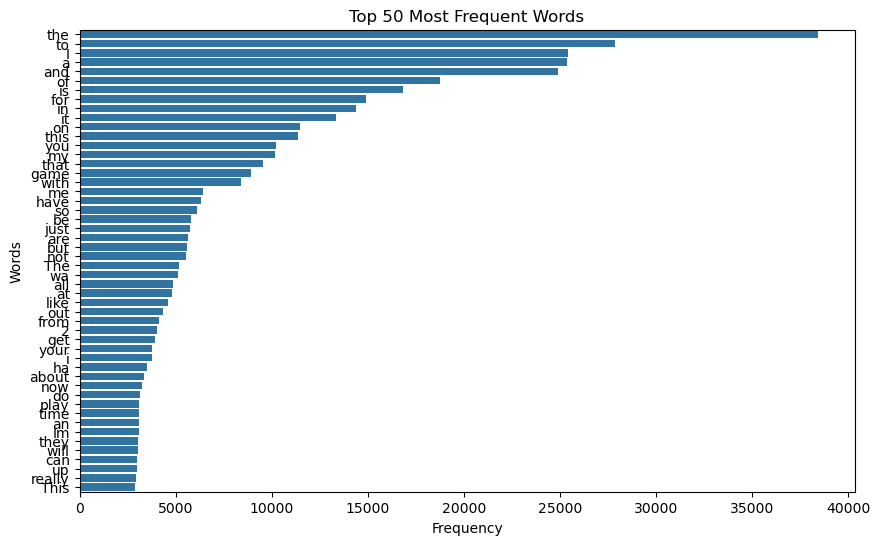

In [103]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['tweet_content']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Example usage
plot_top_n_words(df, n=50)


In [108]:
word_category_counts = {}

for idx, row in df.iterrows():
    words = row['tweet_content'].split()
    category = row['sentiment']  # Assuming 'category' column exists for -1, 0, 1 labels

    for word in words:
        if word not in word_category_counts:
            word_category_counts[word] = { "Negative": 0, "Neutral": 0, "Positive": 0, "Irrelevant": 0 }  # Initialize counts for each sentiment category

        # Increment the count for the corresponding sentiment category
        word_category_counts[word][category] += 1

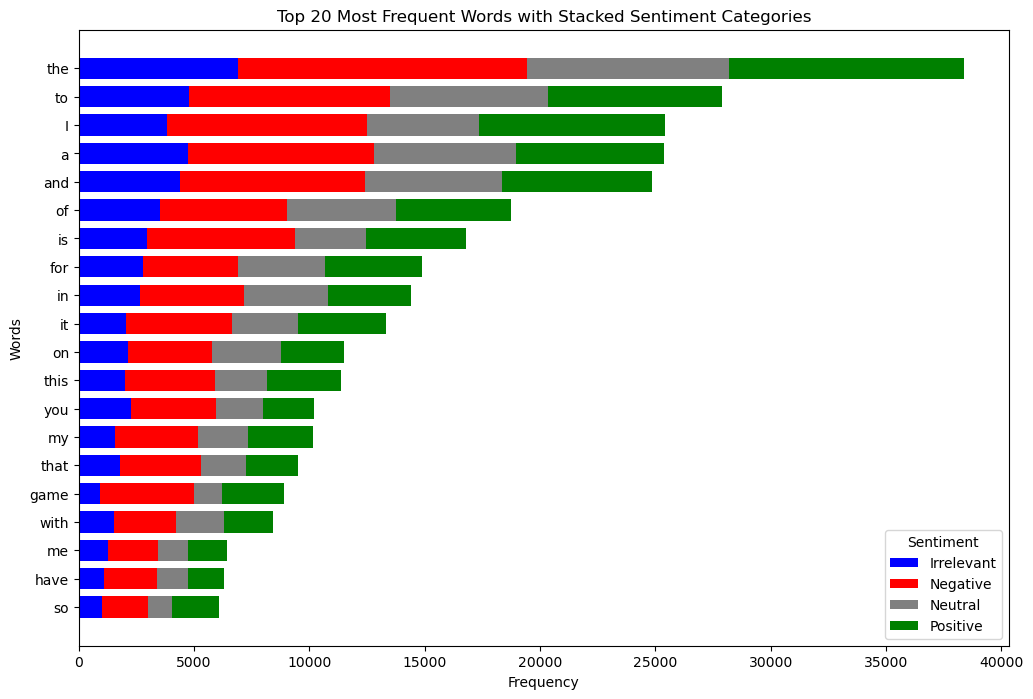

In [118]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['tweet_content'].split()
        category = row['sentiment']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { "Negative": 0, "Neutral": 0, "Positive": 0, "Irrelevant": 0 }  # Initialize counts for each sentiment category

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1
    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word]['Negative'] for word in top_words]
    neutral_counts = [word_category_counts[word]['Neutral'] for word in top_words]
    positive_counts = [word_category_counts[word]['Positive'] for word in top_words]
    irrelevant_counts = [word_category_counts[word]['Irrelevant'] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, irrelevant_counts, color='blue', label='Irrelevant', height=bar_width)

    plt.barh(word_labels, negative_counts,
            left=irrelevant_counts, color='red', label='Negative', height=bar_width)

    plt.barh(word_labels, neutral_counts,
            left=[i + j for i, j in zip(irrelevant_counts, negative_counts)],
            color='gray', label='Neutral', height=bar_width)

    plt.barh(word_labels, positive_counts,
         left=[i + j + k for i, j, k in zip(irrelevant_counts, negative_counts, neutral_counts)],
         color='green', label='Positive', height=bar_width)


    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show()

   
plot_top_n_words_by_category(df, n=20)
